# Практичне завдання №3
## Дослідження ефективності TF-IDF зважених ембеддингів для детекції текстів, згенерованих великими мовними моделями

**Мета:** порівняти Mean Pooling та TF-IDF Weighted Mean для агрегації FastText-векторів документів, перевірити SVM (RBF), Logistic Regression та KNN у бінарній класифікації AI/Human і проаналізувати геометрію отриманих векторних просторів.

**Датасет:** *AI vs Human Text Classification Dataset 2026* (`ai_vs_human_text_2026.csv`).

**Структура роботи (за методичними вказівками):** первинний аналіз → spaCy → FastText → дві стратегії агрегації → класифікація → метрики → t-SNE → confusion matrices → відповіді на дослідницькі питання.

> **Важливо.** Первинний аналіз (розділ 3) виявляє, що датасет синтетичний і містить >50 % дублікатів та лише 58 унікальних шаблонів тексту. Тому, окрім експерименту за методичкою (випадковий split 80/20), у роботу додано **контрольний експеримент зі split за шаблонами** — без нього метрики ≈ 1.0 є артефактом витоку даних, а не показником якості детекції.

### 1. Встановлення бібліотек

> Якщо бібліотеки вже встановлені, клітинку можна виконати повторно — `pip` просто перевірить залежності.

In [1]:
%pip install -q pandas numpy matplotlib seaborn scikit-learn spacy gensim
!python -m spacy download en_core_web_sm

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Note: you may need to restart the kernel to use updated packages.


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

## 2. Імпорт бібліотек та налаштування

In [2]:
import os
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

import spacy
from gensim.models import FastText

from sklearn.model_selection import train_test_split, StratifiedGroupKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (
    f1_score, accuracy_score, balanced_accuracy_score, roc_auc_score,
    confusion_matrix, silhouette_score, pairwise_distances
)
from sklearn.manifold import TSNE

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

# Шукаємо CSV поруч із ноутбуком, а також у типових місцях (Colab / середовище завантажень)
CANDIDATE_PATHS = [
    "ai_vs_human_text_2026.csv",
    "/content/ai_vs_human_text_2026.csv",
    "/mnt/user-data/uploads/ai_vs_human_text_2026.csv",
]
DATA_PATH = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Не знайдено ai_vs_human_text_2026.csv. Покладіть файл поруч із ноутбуком "
        "або змініть DATA_PATH."
    )
print("Бібліотеки успішно імпортовано. Датасет:", DATA_PATH)

Бібліотеки успішно імпортовано. Датасет: ai_vs_human_text_2026.csv


## 3. Завантаження та первинний аналіз датасету

Датасет містить тексти двох класів: **human** — написані людиною та **ai** — згенеровані LLM (`gpt-4o`, `gemini-2.0`). Додаткові поля: домен, модель-джерело, `topic_hint`, `word_count` тощо.

In [3]:
df_raw = pd.read_csv(DATA_PATH)

print("Розмір датасету:", df_raw.shape)
print("\nНазви колонок:", df_raw.columns.tolist())
display(df_raw.head())

print("\nПропущені значення:")
display(df_raw.isna().sum().to_frame("NaN"))

print("\nРозподіл класів:")
display(pd.concat([
    df_raw["label"].value_counts().rename("кількість"),
    df_raw["label"].value_counts(normalize=True).mul(100).round(2).rename("%"),
], axis=1))

print("\nМодель-джерело та домен за класами:")
display(pd.crosstab(df_raw["source_model"], df_raw["label"]))
display(pd.crosstab(df_raw["domain"], df_raw["label"]))

Розмір датасету: (2000, 9)

Назви колонок: ['text_id', 'label', 'source_model', 'domain', 'text_content', 'topic_hint', 'word_count', 'avg_sentence_length', 'generation_method']


,text_id,label,source_model,domain,text_content,topic_hint,word_count,avg_sentence_length,generation_method
0,TXT_0001,human,human,social,can we talk about gene editing ethics for a se...,gene editing ethics,27,13.5,template+human_variation
1,TXT_0002,human,human,social,update on election integrity concerns: it's co...,election integrity concerns,20,10.0,template+human_variation
2,TXT_0003,ai,gemini-2.0,news,Analysts are closely watching developments rel...,climate change adaptation strategies,39,13.0,style_simulation
3,TXT_0004,human,human,academic,This paper examines genomic research breakthro...,genomic research breakthroughs,49,16.3,template+human_variation
4,TXT_0005,ai,gpt-4o,academic,Existing literature on student debt crisis has...,student debt crisis,42,10.8,style_simulation



Пропущені значення:


,NaN
text_id,0
label,0
source_model,0
domain,0
text_content,0
topic_hint,0
word_count,0
avg_sentence_length,0
generation_method,0



Розподіл класів:


,кількість,%
label,,
human,1334,66.7
ai,666,33.3



Модель-джерело та домен за класами:


label,ai,human
source_model,,
gemini-2.0,333,0
gpt-4o,333,0
human,0,1334


label,ai,human
domain,,
academic,222,447
news,222,435
social,222,452


### Перевірка артефактів

Перевіряємо дублікати, порожні тексти та надто короткі документи.

In [4]:
df_raw["text_content"] = df_raw["text_content"].fillna("").astype(str)

n_dup = df_raw["text_content"].duplicated().sum()
print("Повні дублікати рядків (з урахуванням text_id):", df_raw.duplicated().sum())
print(f"Дублікати текстів: {n_dup} із {len(df_raw)} ({n_dup / len(df_raw):.1%})")
print("   у т.ч. за класами:")
display(df_raw[df_raw["text_content"].duplicated()]["label"].value_counts().to_frame("дублікатів"))
print("Порожні тексти:", (df_raw["text_content"].str.strip() == "").sum())
print("Тексти з < 5 слів:", (df_raw["text_content"].str.split().str.len() < 5).sum())

# Чи є той самий текст з різними мітками?
conflicts = df_raw.groupby("text_content")["label"].nunique()
print("Тексти з суперечливими мітками:", int((conflicts > 1).sum()))

Повні дублікати рядків (з урахуванням text_id): 0
Дублікати текстів: 1034 із 2000 (51.7%)
   у т.ч. за класами:


,дублікатів
label,
human,755
ai,279


Порожні тексти: 0
Тексти з < 5 слів: 0
Тексти з суперечливими мітками: 0


**Дублікати треба видалити *до* поділу на train/test.** Інакше той самий текст опиняється і в навчальній, і в тестовій вибірці, і метрики стають завищеними (витік даних). Видаляємо порожні тексти та точні дублікати (залишаємо перше входження).

In [5]:
df = (
    df_raw[df_raw["text_content"].str.strip() != ""]
    .drop_duplicates(subset="text_content", keep="first")
    .reset_index(drop=True)
)
print("Розмір до очищення :", df_raw.shape[0])
print("Розмір після очищення:", df.shape[0])
display(pd.concat([
    df["label"].value_counts().rename("кількість"),
    df["label"].value_counts(normalize=True).mul(100).round(2).rename("%"),
], axis=1))

Розмір до очищення : 2000
Розмір після очищення: 966


,кількість,%
label,,
human,579,59.94
ai,387,40.06


### Структура текстів: шаблони

Тексти мають вигляд «шаблон + тема» (`topic_hint`). Замінимо тему на маркер `<T>` і подивимося, скільки унікальних шаблонів залишилось.

In [6]:
def to_template(row):
    return re.sub(re.escape(row["topic_hint"]), "<T>", row["text_content"], flags=re.IGNORECASE)

df["template"] = df.apply(to_template, axis=1)
df["template_id"] = df["template"].factorize()[0]

n_tpl = df["template_id"].nunique()
tpl_labels = df.groupby("template_id")["label"].nunique()
print("Унікальних текстів:", len(df))
print("Унікальних тем (topic_hint):", df["topic_hint"].nunique())
print("Унікальних шаблонів:", n_tpl)
print("Шаблонів за класами:", df.groupby("label")["template_id"].nunique().to_dict())
print("Шаблонів, що трапляються в обох класах:", int((tpl_labels > 1).sum()))

print("\nПриклад шаблону класу AI:")
print(df[df["label"] == "ai"]["template"].iloc[0])
print("\nПриклад шаблону класу Human:")
print(df[df["label"] == "human"]["template"].iloc[0])

Унікальних текстів: 966
Унікальних тем (topic_hint): 30
Унікальних шаблонів: 58
Шаблонів за класами: {'ai': 18, 'human': 40}
Шаблонів, що трапляються в обох класах: 0

Приклад шаблону класу AI:
Analysts are closely watching developments related to <T>, noting that recent events mark a potential turning point. The situation underscores long-standing structural issues that have resisted easy solutions. Observers remain cautiously optimistic about prospects for reform.

Приклад шаблону класу Human:
can we talk about <T> for a sec because i feel like people are completely missing the point here. this is bigger than most realize


**Висновок первинного аналізу.** Кожен шаблон належить лише одному класу, а тексти відрізняються тільки підставленою темою. Отже, класифікатору достатньо «впізнати шаблон». Якщо шаблон потрапив і в train, і в test, висока якість неминуча. Для чесної оцінки здатності *узагальнювати* потрібен split за шаблонами (розділ 11).

### Розподіл довжини текстів

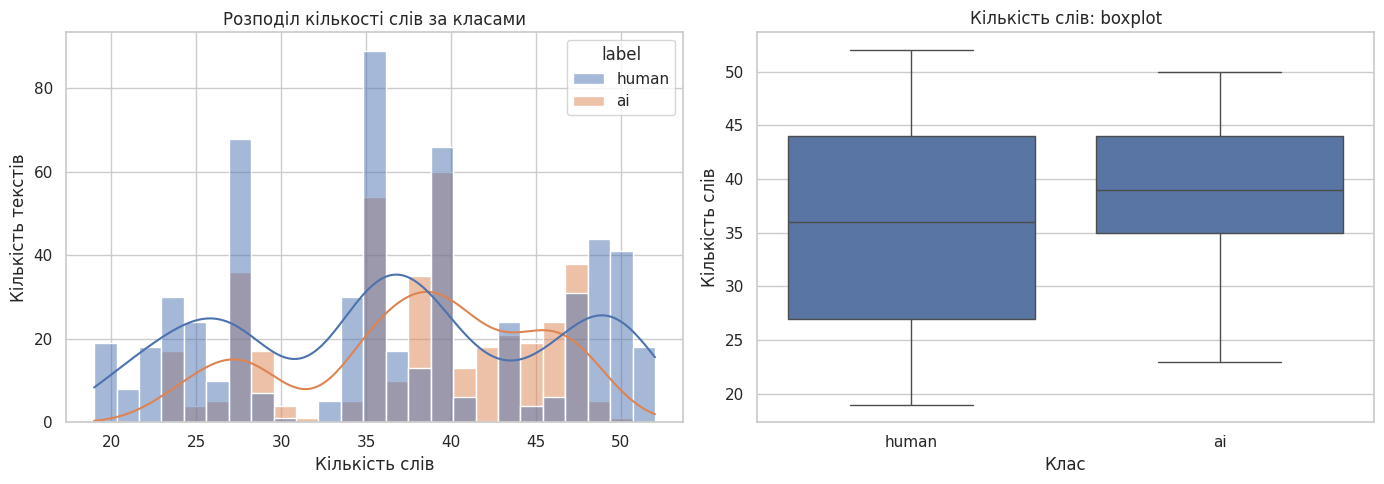

,count,mean,median,std,min,max
label,,,,,,
ai,387,37.93,39.0,7.03,23,50
human,579,36.35,36.0,9.40,19,52


Розбіжностей між calc_word_count і word_count: 0


In [7]:
df["calc_word_count"] = df["text_content"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df, x="calc_word_count", hue="label", bins=25, kde=True, ax=axes[0])
axes[0].set_title("Розподіл кількості слів за класами")
axes[0].set_xlabel("Кількість слів"); axes[0].set_ylabel("Кількість текстів")

sns.boxplot(data=df, x="label", y="calc_word_count", ax=axes[1])
axes[1].set_title("Кількість слів: boxplot")
axes[1].set_xlabel("Клас"); axes[1].set_ylabel("Кількість слів")
plt.tight_layout(); plt.show()

display(
    df.groupby("label")["calc_word_count"]
      .agg(["count", "mean", "median", "std", "min", "max"]).round(2)
)
print("Розбіжностей між calc_word_count і word_count:", int((df["calc_word_count"] != df["word_count"]).sum()))

## 4. Попередня обробка тексту (spaCy)

Відповідно до методички: лематизація, видалення stop words, видалення неалфавітних токенів, нижній регістр. Для швидкості використовуємо `nlp.pipe()` з batching; парсер і NER вимкнено, бо для лематизації вони не потрібні.

In [8]:
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

def preprocess_documents(texts, batch_size=64):
    processed = []
    for doc in nlp.pipe(texts, batch_size=batch_size):
        tokens = [
            token.lemma_.lower()
            for token in doc
            if token.is_alpha and not token.is_stop
        ]
        processed.append(tokens)
    return processed

df["tokens"] = preprocess_documents(df["text_content"].tolist())

print("Приклад оригінального тексту:")
print(df.loc[0, "text_content"])
print("\nПісля preprocessing:")
print(df.loc[0, "tokens"])
print("\nПорожніх token-списків:", (df["tokens"].str.len() == 0).sum())
print("Середня кількість токенів після обробки:", round(df["tokens"].str.len().mean(), 1))

Приклад оригінального тексту:
can we talk about gene editing ethics for a sec because i feel like people are completely missing the point here. this is bigger than most realize

Після preprocessing:
['talk', 'gene', 'edit', 'ethic', 'sec', 'feel', 'like', 'people', 'completely', 'miss', 'point', 'big', 'realize']

Порожніх token-списків: 0
Середня кількість токенів після обробки: 22.0


## 5. Поділ на train/test

Експеримент A відповідає методичці: `80/20` зі `stratify=y`. FastText і TF-IDF навчаємо **лише на train-частині**, щоб не було витоку з тестових даних.

In [9]:
y = (df["label"] == "ai").astype(int).values
indices = np.arange(len(df))

train_idx, test_idx = train_test_split(
    indices, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()
y_train, y_test = y[train_idx], y[test_idx]

print("Train:", len(train_df), "| Test:", len(test_df))
print("Train:", train_df["label"].value_counts().to_dict())
print("Test :", test_df["label"].value_counts().to_dict())

shared = set(train_df["template_id"]) & set(test_df["template_id"])
print(f"\nШаблонів, що є одночасно в train і test: {len(shared)} із {n_tpl}")
print("→ майже кожен тестовий текст має «двійника-шаблон» у train.")

Train: 772 | Test: 194
Train: {'human': 463, 'ai': 309}
Test : {'human': 116, 'ai': 78}

Шаблонів, що є одночасно в train і test: 48 із 58
→ майже кожен тестовий текст має «двійника-шаблон» у train.


## 6. FastText + 7. TF-IDF + 8. Агрегація

Щоб один і той самий код можна було застосувати і до експерименту A, і до крос-валідації за шаблонами, винесемо навчання представлень у функцію `fit_representations`. Вона на кожному train-наборі:

1. навчає FastText (`vector_size=100, window=5, min_count=2, sg=1, seed=42`);
2. навчає `TfidfVectorizer` на тих самих токенах;
3. будує документні вектори двома способами (Mean Pooling та TF-IDF Weighted Mean).

> `workers=1` взято заради відтворюваності: при `workers>1` gensim недетермінований навіть із фіксованим `seed`. Методичка пропонує `workers=4`; на цьому корпусі різниця лише в швидкості.

In [10]:
def mean_pooling(tokens, model):
    vectors = [model.wv[t] for t in tokens if t in model.wv]
    if not vectors:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)


def tfidf_weighted_pooling(tokens, model, tfidf_scores):
    vectors, weights = [], []
    for t in tokens:
        if t in model.wv and t in tfidf_scores:
            vectors.append(model.wv[t])
            weights.append(tfidf_scores[t])
    if not vectors:
        return np.zeros(model.vector_size)
    weights = np.array(weights, dtype=float)
    if weights.sum() == 0:
        return np.mean(vectors, axis=0)
    weights /= weights.sum()
    return np.average(np.array(vectors), axis=0, weights=weights)


def tfidf_row_to_dict(matrix, feature_names):
    # Список {слово: TF-IDF у цьому документі} для кожного рядка sparse-матриці
    return [dict(zip(feature_names[row.indices], row.data)) for row in matrix]


def fit_representations(train_tokens, test_tokens, epochs=10):
    ft = FastText(
        sentences=train_tokens, vector_size=100, window=5, min_count=2,
        sg=1, workers=1, seed=RANDOM_STATE, epochs=epochs
    )
    vec = TfidfVectorizer(lowercase=False, token_pattern=r"(?u)\b\w+\b")
    tf_train = vec.fit_transform([" ".join(t) for t in train_tokens])
    tf_test = vec.transform([" ".join(t) for t in test_tokens])
    names = vec.get_feature_names_out()
    d_train = tfidf_row_to_dict(tf_train, names)
    d_test = tfidf_row_to_dict(tf_test, names)

    feats = {
        "Mean Pooling": (
            np.vstack([mean_pooling(t, ft) for t in train_tokens]),
            np.vstack([mean_pooling(t, ft) for t in test_tokens]),
        ),
        "TF-IDF Weighted Mean": (
            np.vstack([tfidf_weighted_pooling(t, ft, s) for t, s in zip(train_tokens, d_train)]),
            np.vstack([tfidf_weighted_pooling(t, ft, s) for t, s in zip(test_tokens, d_test)]),
        ),
    }
    return feats, ft, vec


feats_A, fasttext_model, tfidf = fit_representations(
    train_df["tokens"].tolist(), test_df["tokens"].tolist()
)
X_train_mean, X_test_mean = feats_A["Mean Pooling"]
X_train_tfidf, X_test_tfidf = feats_A["TF-IDF Weighted Mean"]

print("FastText vocabulary size:", len(fasttext_model.wv))
print("TF-IDF features:", len(tfidf.vocabulary_))
print("Mean Pooling:", X_train_mean.shape, X_test_mean.shape)
print("TF-IDF Weighted Mean:", X_train_tfidf.shape, X_test_tfidf.shape)

FastText vocabulary size: 508
TF-IDF features: 510
Mean Pooling: (772, 100) (194, 100)
TF-IDF Weighted Mean: (772, 100) (194, 100)


## 9. Навчання та оцінювання класифікаторів (Експеримент A — split за методичкою)

Три моделі: **SVM (RBF)**, **Logistic Regression**, **KNN (k=5)**. Метрики: Accuracy, Balanced Accuracy, F1 (macro), ROC-AUC.

In [11]:
def make_classifiers():
    return {
        "SVM": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
        "LogReg": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        "KNN": KNeighborsClassifier(n_neighbors=5),
    }


def evaluate_models(X_train, X_test, y_train, y_test, aggregation_name):
    results, trained = [], {}
    for name, clf in make_classifiers().items():
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        y_prob = clf.predict_proba(X_test)[:, 1]
        results.append({
            "Aggregation": aggregation_name,
            "Classifier": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
            "F1 Macro": f1_score(y_test, y_pred, average="macro"),
            "ROC-AUC": roc_auc_score(y_test, y_prob),
        })
        trained[name] = clf
    return pd.DataFrame(results), trained


mean_results, mean_models = evaluate_models(X_train_mean, X_test_mean, y_train, y_test, "Mean Pooling")
tfidf_results, tfidf_models = evaluate_models(X_train_tfidf, X_test_tfidf, y_train, y_test, "TF-IDF Weighted Mean")

results = pd.concat([mean_results, tfidf_results], ignore_index=True)
METRICS = ["Accuracy", "Balanced Accuracy", "F1 Macro", "ROC-AUC"]
display(results.round(4))

,Aggregation,Classifier,Accuracy,Balanced Accuracy,F1 Macro,ROC-AUC
0,Mean Pooling,SVM,1.0000,1.0000,1.0000,1.0000
1,Mean Pooling,LogReg,0.9485,0.9485,0.9466,0.9912
2,Mean Pooling,KNN,1.0000,1.0000,1.0000,1.0000
3,TF-IDF Weighted Mean,SVM,1.0000,1.0000,1.0000,1.0000
4,TF-IDF Weighted Mean,LogReg,0.9639,0.9656,0.9627,0.9935
5,TF-IDF Weighted Mean,KNN,1.0000,1.0000,1.0000,1.0000


### Порівняння результатів

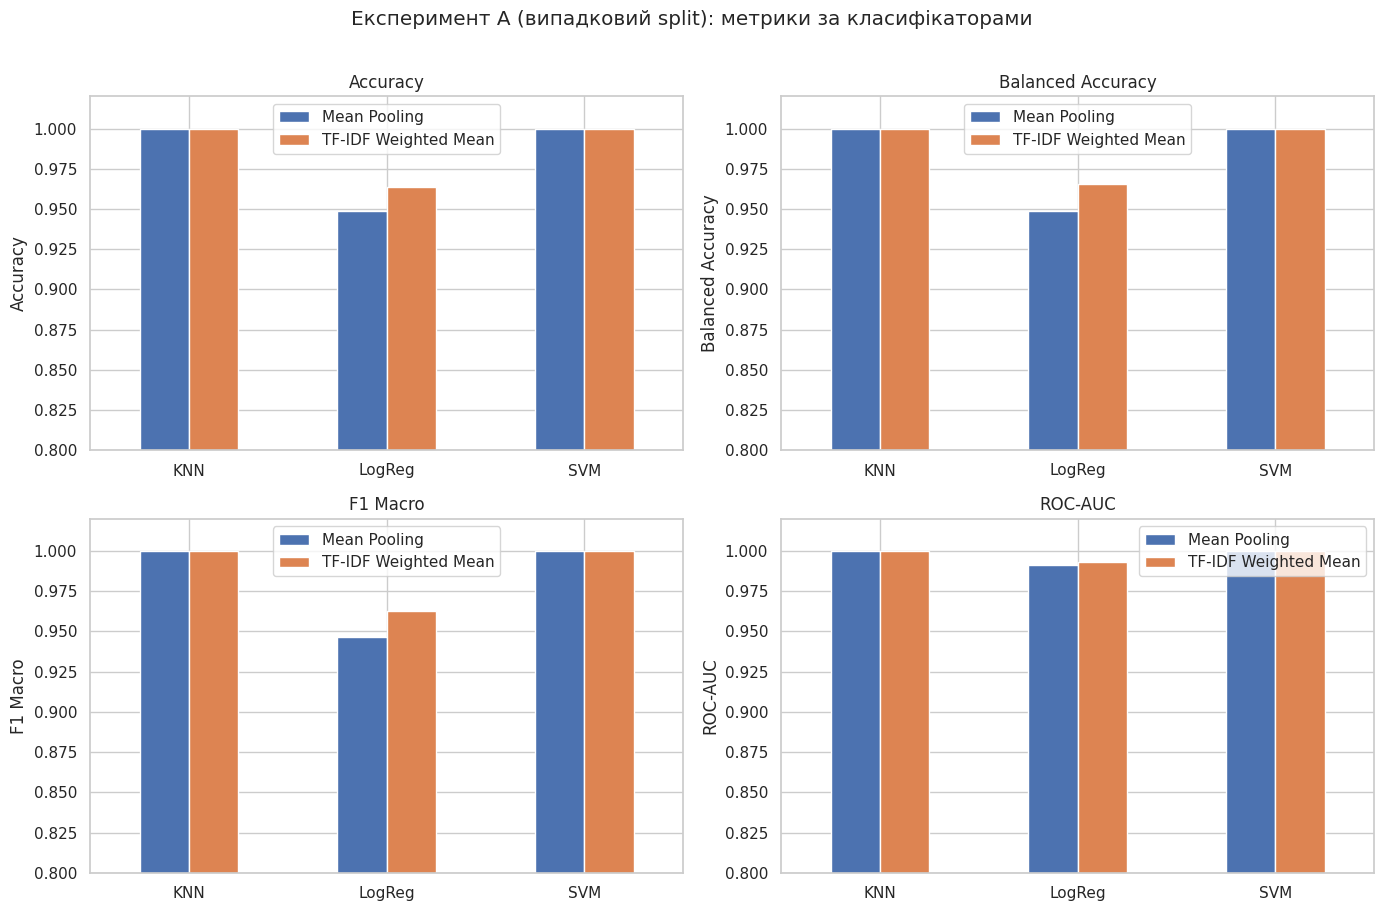

Найкраща комбінація за кожною метрикою (при рівності — перша за порядком):


,Комбінація,Значення
Accuracy,Mean Pooling + SVM,1.0
Balanced Accuracy,Mean Pooling + SVM,1.0
F1 Macro,Mean Pooling + SVM,1.0
ROC-AUC,Mean Pooling + SVM,1.0


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, metric in zip(axes.ravel(), METRICS):
    pivot = results.pivot(index="Classifier", columns="Aggregation", values=metric)
    pivot.plot(kind="bar", ax=ax)
    ax.set_title(metric); ax.set_ylabel(metric); ax.set_xlabel("")
    ax.set_ylim(0.8, 1.02)
    ax.tick_params(axis="x", rotation=0); ax.legend(title="")
plt.suptitle("Експеримент A (випадковий split): метрики за класифікаторами", y=1.01)
plt.tight_layout(); plt.show()

print("Найкраща комбінація за кожною метрикою (при рівності — перша за порядком):")
best_per_metric = pd.DataFrame({
    m: {
        "Комбінація": f"{results.loc[results[m].idxmax(), 'Aggregation']} + {results.loc[results[m].idxmax(), 'Classifier']}",
        "Значення": round(results[m].max(), 4),
    } for m in METRICS
}).T
display(best_per_metric)

## 10. Confusion matrices

- TN — Human правильно визначено як Human; FP — Human помилково визначено як AI;
- FN — AI помилково визначено як Human; TP — AI правильно визначено як AI.

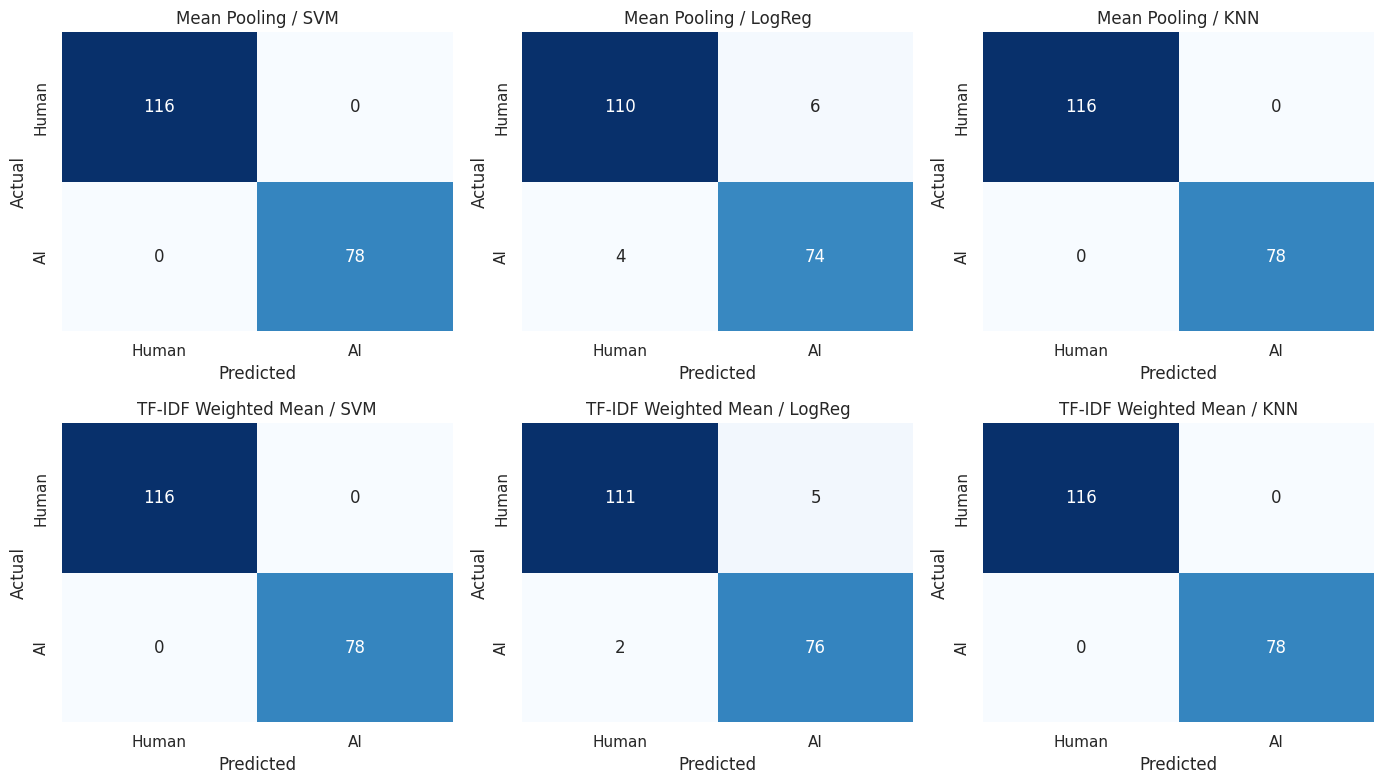

In [13]:
pairs = [("Mean Pooling", X_test_mean, mean_models), ("TF-IDF Weighted Mean", X_test_tfidf, tfidf_models)]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for row, (agg_name, X_te, models) in enumerate(pairs):
    for col, (model_name, model) in enumerate(models.items()):
        cm = confusion_matrix(y_test, model.predict(X_te))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                    xticklabels=["Human", "AI"], yticklabels=["Human", "AI"], ax=axes[row, col])
        axes[row, col].set_title(f"{agg_name} / {model_name}")
        axes[row, col].set_xlabel("Predicted"); axes[row, col].set_ylabel("Actual")
plt.tight_layout(); plt.show()

## 11. Експеримент B — split за шаблонами (чесна оцінка узагальнення)

У датасеті 58 шаблонів, і кожен належить одному класу. `StratifiedGroupKFold` (5 фолдів, `groups = template_id`) гарантує, що **жоден шаблон не потрапляє одночасно в train і test**. Тоді модель мусить розпізнавати *стиль*, а не запам'ятовувати конкретне формулювання. На кожному фолді FastText і TF-IDF навчаються заново лише на train-частині.

In [14]:
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
groups = df["template_id"].values

fold_results = []
for fold, (tr, te) in enumerate(sgkf.split(indices, y, groups)):
    assert not (set(groups[tr]) & set(groups[te])), "витік шаблонів між train і test"
    feats_f, _, _ = fit_representations(df["tokens"].iloc[tr].tolist(), df["tokens"].iloc[te].tolist())
    for agg_name, (Xa, Xb) in feats_f.items():
        res_f, _ = evaluate_models(Xa, Xb, y[tr], y[te], agg_name)
        res_f["Fold"] = fold
        fold_results.append(res_f)
    print(f"fold {fold}: train={len(tr)}, test={len(te)}, спільних шаблонів = 0")

cv_results = pd.concat(fold_results, ignore_index=True)
cv_summary = cv_results.groupby(["Aggregation", "Classifier"])[METRICS].agg(["mean", "std"]).round(3)
display(cv_summary)

fold 0: train=766, test=200, спільних шаблонів = 0


fold 1: train=766, test=200, спільних шаблонів = 0


fold 2: train=783, test=183, спільних шаблонів = 0


fold 3: train=783, test=183, спільних шаблонів = 0


fold 4: train=766, test=200, спільних шаблонів = 0


Accuracy        Balanced Accuracy         \
                                    mean    std              mean    std   
Aggregation          Classifier                                            
Mean Pooling         KNN           0.658  0.059             0.616  0.119   
                     LogReg        0.609  0.175             0.655  0.166   
                     SVM           0.650  0.133             0.702  0.121   
TF-IDF Weighted Mean KNN           0.629  0.114             0.589  0.121   
                     LogReg        0.573  0.197             0.589  0.200   
                     SVM           0.615  0.232             0.647  0.240   

                                F1 Macro        ROC-AUC         
                                    mean    std    mean    std  
Aggregation          Classifier                                 
Mean Pooling         KNN           0.560  0.171   0.634  0.209  
                     LogReg        0.598  0.186   0.588  0.198  
                     SVM           0.643  0.141   0.663  0.208  
TF-IDF Weighted Mean KNN           0.574  0.136   0.636  0.074  
                     LogReg        0.569  0.200   0.561  0.206  
                     SVM           0.613  0.234   0.593  0.218

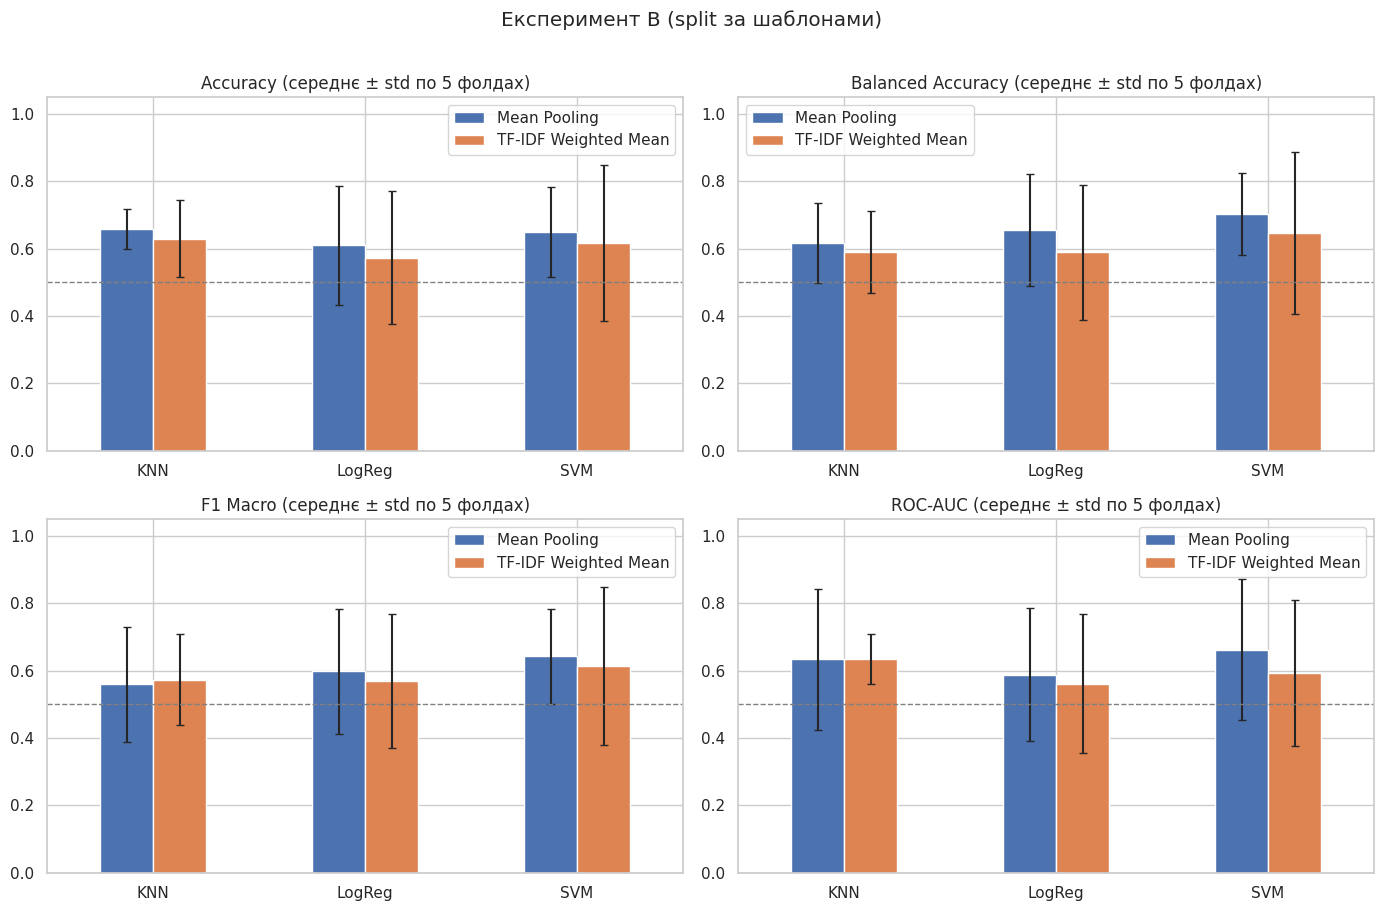

In [15]:
cv_mean = cv_results.groupby(["Aggregation", "Classifier"])[METRICS].mean().reset_index()
cv_std = cv_results.groupby(["Aggregation", "Classifier"])[METRICS].std().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, metric in zip(axes.ravel(), METRICS):
    p_mean = cv_mean.pivot(index="Classifier", columns="Aggregation", values=metric)
    p_std = cv_std.pivot(index="Classifier", columns="Aggregation", values=metric)
    p_mean.plot(kind="bar", yerr=p_std, ax=ax, capsize=3)
    ax.axhline(0.5, color="gray", ls="--", lw=1)
    ax.set_title(f"{metric} (середнє ± std по 5 фолдах)")
    ax.set_ylim(0, 1.05); ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0); ax.legend(title="")
plt.suptitle("Експеримент B (split за шаблонами)", y=1.01)
plt.tight_layout(); plt.show()

## 12. t-SNE: геометрія простору документів

t-SNE проєктує 100-вимірні документні вектори у 2D. Окремі графіки для Mean Pooling і TF-IDF Weighted Mean (тестова частина експерименту A). Праворуч ті самі точки розфарбовані за **шаблоном**, щоб перевірити, чи кластери відповідають класу чи конкретному шаблону.

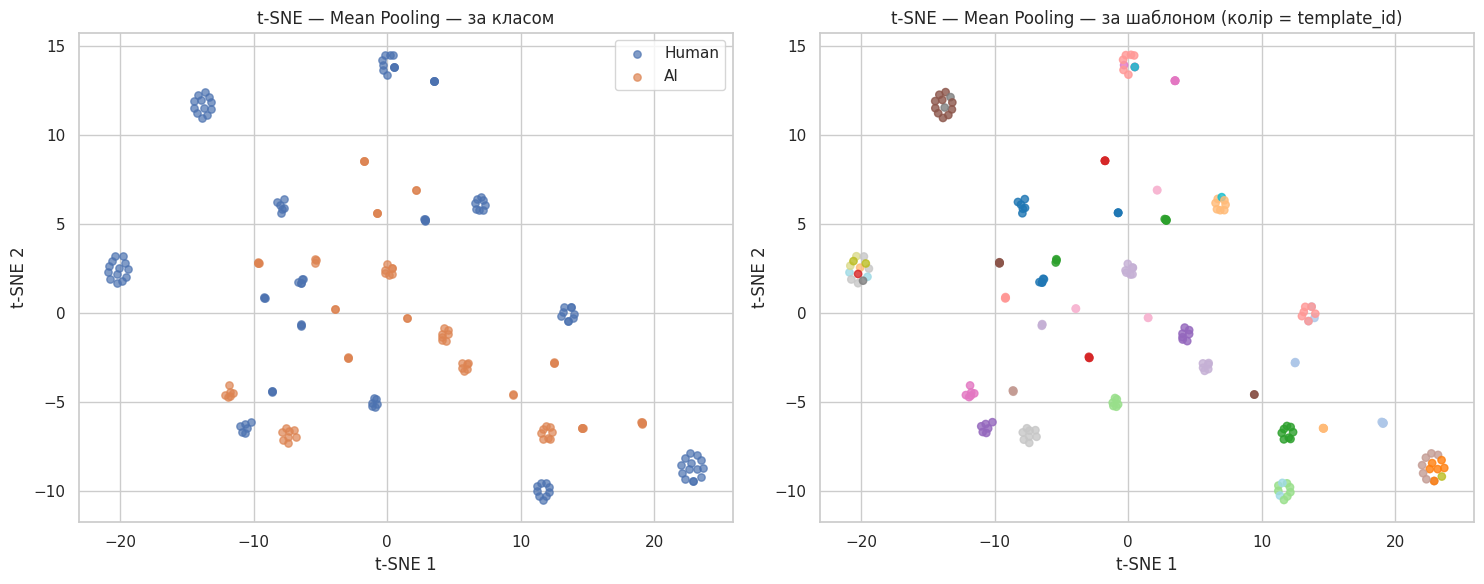

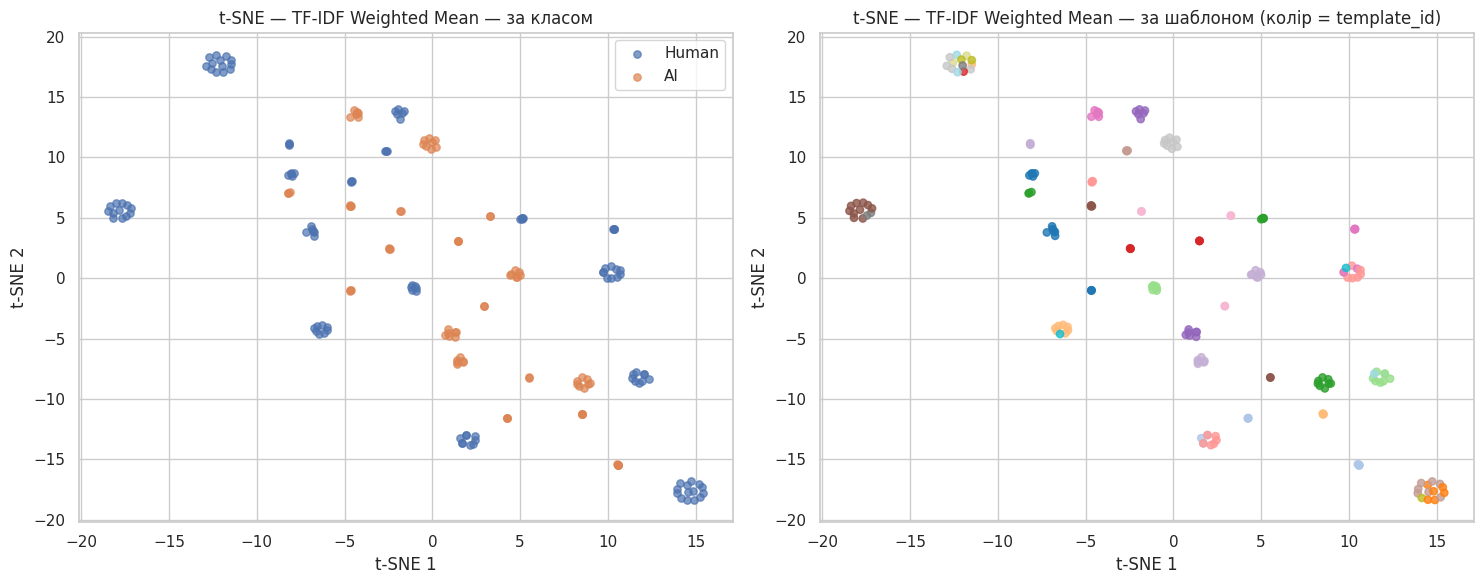

In [16]:
def plot_tsne(X, y_vec, tpl, title):
    perplexity = min(30, max(5, len(X) // 10))
    X_2d = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=perplexity,
                init="pca", learning_rate="auto").fit_transform(X)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    for val, name in [(0, "Human"), (1, "AI")]:
        m = y_vec == val
        axes[0].scatter(X_2d[m, 0], X_2d[m, 1], label=name, alpha=0.7, s=28)
    axes[0].set_title(f"{title} — за класом"); axes[0].legend()

    sc = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=tpl, cmap="tab20", alpha=0.8, s=28)
    axes[1].set_title(f"{title} — за шаблоном (колір = template_id)")
    for ax in axes:
        ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
    plt.tight_layout(); plt.show()

test_tpl = test_df["template_id"].values
plot_tsne(X_test_mean, y_test, test_tpl, "t-SNE — Mean Pooling")
plot_tsne(X_test_tfidf, y_test, test_tpl, "t-SNE — TF-IDF Weighted Mean")

## 13. Геометричний аналіз просторів

Щоб відповісти на дослідницькі питання 1, 3 і 5 числами, а не лише «на око», порахуємо для обох представлень (на train-вибірці експерименту A):

- **Silhouette (euclid / cosine)** за мітками класів — наскільки компактні й відокремлені класи;
- **Fisher ratio** — відстань між центроїдами класів / середній внутрішньокласовий розкид;
- **Relative contrast** `(d_max − d_min) / d_mean` для відстаней точка→інші точки — міра концентрації відстаней (прокляття розмірності): чим ближче до 0, тим менш інформативні відстані для KNN. Нормування на `d_mean`, а не на `d_min`, бо частина документів має майже ідентичні вектори;
- **Середня норма та її std** — як агрегація змінює масштаб векторів;
- **Ефективна розмірність** — кількість головних компонент для 90 % дисперсії.

In [17]:
def geometry_report(X, y_vec, name):
    D = pairwise_distances(X)
    np.fill_diagonal(D, np.nan)
    d_min, d_max, d_mean = np.nanmin(D, axis=1), np.nanmax(D, axis=1), np.nanmean(D, axis=1)
    # Нормуємо на середню відстань (а не на d_min): у корпусі є документи з майже
    # однаковими векторами (d_min ≈ 0), і ділення на d_min дало б безглузді значення.
    contrast = np.mean((d_max - d_min) / d_mean)
    n_near_dup = int((d_min < 1e-6).sum())

    c0, c1 = X[y_vec == 0].mean(axis=0), X[y_vec == 1].mean(axis=0)
    within = 0.5 * (np.linalg.norm(X[y_vec == 0] - c0, axis=1).mean()
                    + np.linalg.norm(X[y_vec == 1] - c1, axis=1).mean())
    norms = np.linalg.norm(X, axis=1)
    n_pc = int(np.searchsorted(np.cumsum(PCA().fit(X).explained_variance_ratio_), 0.90) + 1)

    return {
        "Aggregation": name,
        "Silhouette (euclid)": silhouette_score(X, y_vec),
        "Silhouette (cosine)": silhouette_score(X, y_vec, metric="cosine"),
        "Fisher ratio": np.linalg.norm(c0 - c1) / within,
        "Relative contrast": contrast,
        "Docs with near-identical twin": n_near_dup,
        "Mean norm": norms.mean(),
        "Std of norm": norms.std(),
        "PCs for 90% var": n_pc,
    }

geometry = pd.DataFrame([
    geometry_report(X_train_mean, y_train, "Mean Pooling"),
    geometry_report(X_train_tfidf, y_train, "TF-IDF Weighted Mean"),
]).set_index("Aggregation")
display(geometry.round(4))

# Наскільки TF-IDF зважування взагалі змінює документні вектори?
cos_sim = np.sum(X_train_mean * X_train_tfidf, axis=1) / (
    np.linalg.norm(X_train_mean, axis=1) * np.linalg.norm(X_train_tfidf, axis=1) + 1e-12)
rel_shift = np.linalg.norm(X_train_tfidf - X_train_mean, axis=1) / (np.linalg.norm(X_train_mean, axis=1) + 1e-12)
print(f"Косинусна подібність Mean vs TF-IDF для того самого документа: "
      f"середня = {cos_sim.mean():.4f}, мінімум = {cos_sim.min():.4f}")
print(f"Відносний зсув вектора ||v_tfidf − v_mean|| / ||v_mean||: середній = {rel_shift.mean():.4f}")

idf_vals = np.array(list(dict(zip(tfidf.get_feature_names_out(), tfidf.idf_)).values()))
print(f"IDF: min = {idf_vals.min():.2f}, median = {np.median(idf_vals):.2f}, max = {idf_vals.max():.2f}, "
      f"std = {idf_vals.std():.2f}")
print(f"Середня довжина документа після обробки: {np.mean([len(t) for t in train_df['tokens']]):.1f} токенів")

,Silhouette (euclid),Silhouette (cosine),Fisher ratio,Relative contrast,Docs with near-identical twin,Mean norm,Std of norm,PCs for 90% var
Aggregation,,,,,,,,
Mean Pooling,0.0400,0.0452,0.3822,1.2142,114,2.9066,0.2947,13
TF-IDF Weighted Mean,0.0414,0.0486,0.3853,1.2075,114,2.9130,0.2934,13


Косинусна подібність Mean vs TF-IDF для того самого документа: середня = 0.9995, мінімум = 0.9968
Відносний зсув вектора ||v_tfidf − v_mean|| / ||v_mean||: середній = 0.0294
IDF: min = 2.50, median = 4.43, max = 6.96, std = 0.56
Середня довжина документа після обробки: 21.9 токенів


## 14. Лінгвістична інтерпретація: слова та біграми з найбільшим TF-IDF у класі AI

Порівнюємо **середній TF-IDF у класі AI** з **середнім у класі Human** на train-частині. Розбіжність `mean_AI − mean_Human` показує слова, що *характерні саме для AI*, а не просто часті в усьому корпусі. Те саме робимо для біграм.

Це **не доводить**, що ці слова є універсальними маркерами AI: результат залежить від конкретного датасету.

Топ-15 слів за середнім TF-IDF у AI (за абсолютним значенням):


,Term,Mean TF-IDF AI,Mean TF-IDF Human,Diff (AI-Human)
0,challenge,0.0402,0.0228,0.0174
1,framework,0.0338,0.0135,0.0204
2,conversation,0.0318,0.0114,0.0204
3,solution,0.0311,0.0000,0.0311
4,think,0.0307,0.0000,0.0307
5,point,0.0306,0.0100,0.0206
6,datum,0.0285,0.0181,0.0104
7,expert,0.0282,0.0000,0.0282
8,underscore,0.0276,0.0000,0.0276
9,stakeholder,0.0275,0.0000,0.0275


Топ-15 слів, найхарактерніших для AI (AI − Human):


,Term,Mean TF-IDF AI,Mean TF-IDF Human,Diff (AI-Human)
0,solution,0.0311,0.0,0.0311
1,think,0.0307,0.0,0.0307
2,expert,0.0282,0.0,0.0282
3,underscore,0.0276,0.0,0.0276
4,stakeholder,0.0275,0.0,0.0275
5,development,0.0268,0.0,0.0268
6,recommendation,0.0264,0.0,0.0264
7,potential,0.0261,0.0,0.0261
8,recommend,0.0260,0.0,0.0260
9,follow,0.0260,0.0,0.0260


Топ-10 біграм, найхарактерніших для AI (AI − Human):


,Term,Mean TF-IDF AI,Mean TF-IDF Human,Diff (AI-Human)
0,acknowledge complexity,0.0220,0.0,0.0220
1,reduce talk,0.0220,0.0,0.0220
2,complexity instead,0.0220,0.0,0.0220
3,exhausting acknowledge,0.0220,0.0,0.0220
4,instead reduce,0.0220,0.0,0.0220
5,talk point,0.0220,0.0,0.0220
6,potential approach,0.0209,0.0,0.0209
7,fascinating quickly,0.0209,0.0,0.0209
8,quickly thing,0.0209,0.0,0.0209
9,thoughtfully thought,0.0209,0.0,0.0209


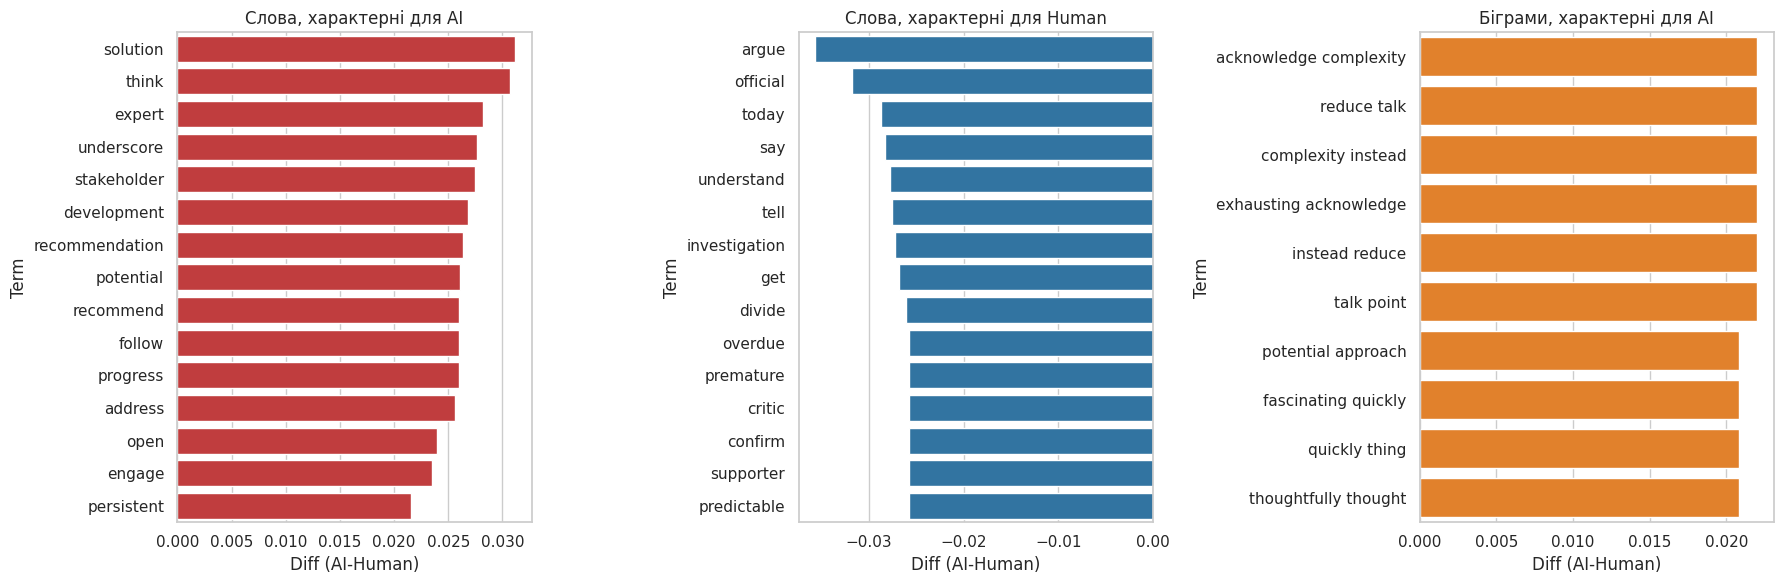

In [18]:
def class_term_scores(tokens_series, labels, ngram_range=(1, 1), min_df=3):
    vec = TfidfVectorizer(lowercase=False, token_pattern=r"(?u)\b\w+\b",
                          ngram_range=ngram_range, min_df=min_df)
    M = vec.fit_transform(tokens_series.apply(lambda x: " ".join(x)))
    terms = vec.get_feature_names_out()
    m_ai = np.asarray(M[labels == 1].mean(axis=0)).ravel()
    m_hu = np.asarray(M[labels == 0].mean(axis=0)).ravel()
    return pd.DataFrame({"Term": terms, "Mean TF-IDF AI": m_ai,
                         "Mean TF-IDF Human": m_hu, "Diff (AI-Human)": m_ai - m_hu})

uni = class_term_scores(train_df["tokens"], y_train, (1, 1))
bi = class_term_scores(train_df["tokens"], y_train, (2, 2))

print("Топ-15 слів за середнім TF-IDF у AI (за абсолютним значенням):")
display(uni.sort_values("Mean TF-IDF AI", ascending=False).head(15).round(4).reset_index(drop=True))
print("Топ-15 слів, найхарактерніших для AI (AI − Human):")
display(uni.sort_values("Diff (AI-Human)", ascending=False).head(15).round(4).reset_index(drop=True))
print("Топ-10 біграм, найхарактерніших для AI (AI − Human):")
display(bi.sort_values("Diff (AI-Human)", ascending=False).head(10).round(4).reset_index(drop=True))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
top_ai = uni.sort_values("Diff (AI-Human)", ascending=False).head(15)
top_hu = uni.sort_values("Diff (AI-Human)", ascending=True).head(15)
sns.barplot(data=top_ai, x="Diff (AI-Human)", y="Term", ax=axes[0], color="tab:red")
axes[0].set_title("Слова, характерні для AI")
sns.barplot(data=top_hu, x="Diff (AI-Human)", y="Term", ax=axes[1], color="tab:blue")
axes[1].set_title("Слова, характерні для Human")
top_bi = bi.sort_values("Diff (AI-Human)", ascending=False).head(10)
sns.barplot(data=top_bi, x="Diff (AI-Human)", y="Term", ax=axes[2], color="tab:orange")
axes[2].set_title("Біграми, характерні для AI")
plt.tight_layout(); plt.show()

### Скільки «маркерних» слів існують лише в одному класі?

Перевіримо, чи характерні слова зустрічаються також у людських текстах. Якщо слово має ненульовий TF-IDF лише в AI-класі, це ознака шаблонного, а не стилістичного розрізнення.

In [19]:
vocab_ai = set(t for toks in train_df[train_df["label"] == "ai"]["tokens"] for t in toks)
vocab_hu = set(t for toks in train_df[train_df["label"] == "human"]["tokens"] for t in toks)
only_ai, only_hu, both = vocab_ai - vocab_hu, vocab_hu - vocab_ai, vocab_ai & vocab_hu
print(f"Словник AI: {len(vocab_ai)} | Human: {len(vocab_hu)} | спільних: {len(both)}")
print(f"Слів лише в AI: {len(only_ai)} ({len(only_ai) / len(vocab_ai):.0%} словника AI)")
print(f"Слів лише в Human: {len(only_hu)} ({len(only_hu) / len(vocab_hu):.0%} словника Human)")
print("\nЧастка топ-15 AI-маркерів, яких немає в Human-текстах:",
      f"{np.mean([t in only_ai for t in top_ai['Term']]):.0%}")

Словник AI: 358 | Human: 320 | спільних: 168
Слів лише в AI: 190 (53% словника AI)
Слів лише в Human: 152 (48% словника Human)

Частка топ-15 AI-маркерів, яких немає в Human-текстах: 100%


## 15. Автоматично сформовані висновки за числами

Клітинка нижче формує підсумки з реальних значень, тому її вивід завжди відповідає останньому запуску.

In [20]:
def best_of(frame, col="F1 Macro"):
    return frame.loc[frame[col].idxmax()]

bA = best_of(results)
mA, tA = mean_results["F1 Macro"], tfidf_results["F1 Macro"]
cvm = cv_results.groupby(["Aggregation", "Classifier"])["F1 Macro"].mean().unstack(0)

print("=== ПІДСУМКОВИЙ АНАЛІЗ ===\n")
print("Експеримент A (випадковий split, дублікати вилучено):")
print(f"  найкраща комбінація: {bA['Aggregation']} + {bA['Classifier']} (F1 = {bA['F1 Macro']:.4f})")
print(f"  максимальний F1: Mean = {mA.max():.4f}, TF-IDF = {tA.max():.4f}")
print(f"  KNN: Mean = {mean_results.set_index('Classifier').loc['KNN','F1 Macro']:.4f} → "
      f"TF-IDF = {tfidf_results.set_index('Classifier').loc['KNN','F1 Macro']:.4f}")
print(f"  LogReg: Mean = {mean_results.set_index('Classifier').loc['LogReg','F1 Macro']:.4f} → "
      f"TF-IDF = {tfidf_results.set_index('Classifier').loc['LogReg','F1 Macro']:.4f}")

print("\nЕксперимент B (split за шаблонами), середній F1 Macro по 5 фолдах:")
display(cvm.round(3))
maj = max(np.mean(y), 1 - np.mean(y))
print(f"  базові рівні: ROC-AUC випадкового класифікатора = 0.5; Accuracy «завжди Human» ≈ {maj:.3f}")
acc_cv = cv_results.groupby(["Aggregation", "Classifier"])["Accuracy"].mean()
print("  середня Accuracy (B):", acc_cv.round(3).to_dict())
best_cv = cv_results.groupby(["Aggregation", "Classifier"])["F1 Macro"].mean().idxmax()
print(f"  найкраща комбінація: {best_cv[0]} + {best_cv[1]}")
gain = (cvm["TF-IDF Weighted Mean"] - cvm["Mean Pooling"]).round(3)
print("  різниця TF-IDF − Mean за класифікаторами:", gain.to_dict())

fold_std = cv_results.groupby(["Aggregation", "Classifier"])["F1 Macro"].std().max()
print(f"  максимальне std між фолдами: {fold_std:.3f} — різниці між методами менші або співмірні з цим розкидом"
      if abs(gain).max() <= fold_std else
      f"  максимальне std між фолдами: {fold_std:.3f}")

print("\nГеометрія (train):")
print(geometry[["Silhouette (cosine)", "Fisher ratio", "Relative contrast"]].round(3).to_string())

=== ПІДСУМКОВИЙ АНАЛІЗ ===

Експеримент A (випадковий split, дублікати вилучено):
  найкраща комбінація: Mean Pooling + SVM (F1 = 1.0000)
  максимальний F1: Mean = 1.0000, TF-IDF = 1.0000
  KNN: Mean = 1.0000 → TF-IDF = 1.0000
  LogReg: Mean = 0.9466 → TF-IDF = 0.9627

Експеримент B (split за шаблонами), середній F1 Macro по 5 фолдах:


Aggregation,Mean Pooling,TF-IDF Weighted Mean
Classifier,,
KNN,0.560,0.574
LogReg,0.598,0.569
SVM,0.643,0.613


  базові рівні: ROC-AUC випадкового класифікатора = 0.5; Accuracy «завжди Human» ≈ 0.599
  середня Accuracy (B): {('Mean Pooling', 'KNN'): 0.658, ('Mean Pooling', 'LogReg'): 0.609, ('Mean Pooling', 'SVM'): 0.65, ('TF-IDF Weighted Mean', 'KNN'): 0.629, ('TF-IDF Weighted Mean', 'LogReg'): 0.573, ('TF-IDF Weighted Mean', 'SVM'): 0.615}
  найкраща комбінація: Mean Pooling + SVM
  різниця TF-IDF − Mean за класифікаторами: {'KNN': 0.014, 'LogReg': -0.03, 'SVM': -0.029}
  максимальне std між фолдами: 0.234 — різниці між методами менші або співмірні з цим розкидом

Геометрія (train):
                      Silhouette (cosine)  Fisher ratio  Relative contrast
Aggregation                                                               
Mean Pooling                        0.045         0.382              1.214
TF-IDF Weighted Mean                0.049         0.385              1.207


# Висновки та відповіді на дослідницькі питання

> Числа нижче отримано при `RANDOM_STATE=42`, `workers=1` (запуск відтворюваний). Якщо змінити параметри — звіряйте з виводом розділів 9–15.

## Головний результат

**Дослідницька гіпотеза (TF-IDF зважування покращує лінійну роздільність класів) на цьому датасеті не підтвердилась.** Крім того, сам датасет не дозволяє зробити висновок про якість детекції AI-текстів:

- з 2000 рядків **1034 (51,7 %) — дублікати**; унікальних текстів 966;
- усі тексти зібрано з **58 шаблонів × 30 тем**; 18 шаблонів — AI, 40 — Human, жоден шаблон не трапляється в обох класах;
- при випадковому split 80/20 **48 із 58 шаблонів є і в train, і в test**, тому SVM та KNN отримують F1 = 1.000. Це «пошук шаблону-двійника», а не детекція стилю;
- при split за шаблонами (Експеримент B) F1 macro падає до **0,56–0,64**, ROC-AUC до **0,56–0,66** (випадковий рівень — 0,5), а Accuracy (0,57–0,66) ледь перевищує тривіальний «завжди Human» (0,599). Розкид між фолдами (std F1 0,14–0,23) більший за різницю між методами.

## Відповіді на дослідницькі питання

**1. Вплив агрегації.** TF-IDF практично не змінює геометрію: косинусна подібність Mean- і TF-IDF-вектора того самого документа в середньому **0,9995** (мінімум 0,9968), відносний зсув вектора лише **2,9 %**. Silhouette за класами 0,040 → 0,041 (euclid) і 0,045 → 0,049 (cosine), Fisher ratio 0,382 → 0,385, ефективна розмірність однакова (13 PC для 90 % дисперсії). Причини: (а) документи дуже короткі — ≈22 токени, більшість термінів зустрічається по 1 разу, тож `tf` майже плоский; (б) IDF у вузькому діапазоні 2,5–6,96 (std 0,56), бо слова шаблону повторюються у десятках документів; (в) після L1-нормування ваг вектор залишається середнім ~20 схожих векторів. Лінійна роздільність не покращується: у Експерименті A LogReg F1 0,947 → 0,963 (≈3 документи з 194 в тесті), а в Експерименті B LogReg, навпаки, 0,598 → 0,569. Обидві зміни в межах шуму.

**2. Порівняння класифікаторів.** У Експерименті A **SVM (RBF) і KNN ідеальні для обох агрегацій (F1 = 1,000)**, LogReg слабший (0,947 / 0,963). Класи — це не дві «хмари», а десятки компактних кластерів-шаблонів, розташованих на різних ділянках простору, тому лінійна межа не підходить, а нелінійний SVM та локальний KNN підходять. У Експерименті B найкращий SVM для обох агрегацій (F1 0,643 для Mean і 0,613 для TF-IDF), але переваги над LogReg/KNN не перевищують розкиду між фолдами.

**3. Чутливість KNN.** Припущення про деградацію KNN при переході до TF-IDF **не підтвердилось**: у A F1 1,000 → 1,000; у B F1 0,560 → 0,574 (Accuracy 0,658 → 0,629) — змішана, статистично невизначена зміна. Контраст відстаней `(d_max − d_min)/d_mean` практично однаковий (1,214 і 1,207), середня норма (2,907 і 2,913) та її розкид теж. Концентрації відстаней, що вбиває KNN, не спостерігається: внутрішня розмірність низька (13 PC), а не 100. Теоретично зважування *могло б* зашкодити KNN, посиливши шум від рідкісних слів, але при такій слабкій зміні векторів цей ефект не виникає.

**4. Лінгвістична інтерпретація.** Найхарактерніші для AI слова (за `mean TF-IDF_AI − mean TF-IDF_Human`): *solution, think, expert, underscore, stakeholder, development, recommendation, potential, recommend, progress, address, engage, persistent*; біграми — *acknowledge complexity, reduce talk, potential approach, fascinating quickly*. Стилістично це типова «корпоративно-ввічлива» лексика LLM (hedging, «underscore», «stakeholder»). Але **100 % топ-15 маркерів повністю відсутні в Human-текстах**, а ≈53 % словника AI не зустрічається в Human, що є ознакою шаблонної, а не статистичної різниці. Тому це маркери 18 конкретних AI-шаблонів цього датасету, а не доведені універсальні ознаки AI-тексту.

**5. Геометричний аналіз.** На t-SNE видно **щільні компактні кластери, але вони відповідають шаблонам, а не класам** (права панель, розфарбована за `template_id`). Кластери Human та AI розсіяні по всьому простору й чергуються. Це узгоджується з Silhouette за класами ≈ 0,04–0,05 (≈ 0 = класи перекриваються) при візуально «чистих» шаблонних кластерах. TF-IDF Weighted Mean дає майже таку саму картину, що й Mean Pooling (Silhouette 0,045 → 0,049 — різниця у третьому знаку); переконливо кращого методу агрегації за кластеризацією немає.

## Обмеження та рекомендації

- Дані синтетичні (`generation_method`: `template+human_variation` та `style_simulation`), тому результати не переносяться на реальні тексти LLM.
- Для реальної перевірки гіпотези потрібен корпус з довшими, різноманітнішими текстами, де `tf` та IDF справді варіюються, і split, який не пропускає між train і test однакових шаблонів / тем / джерел.
- Додатково варто порівняти з baseline на TF-IDF-матриці напряму (LogReg/SVM на розрідженому TF-IDF) і зробити перебір гіперпараметрів (`C`, `gamma`, `k`).